   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.4 MB/s eta 0:00:00
File found: True
Shape: (51, 9)
                 Arc  Start onChapter  TotalChapters  TotalPages Manga%  \
0   Romance Dawn Arc                1              7         178   0.9%   
1    Orange Town Arc                8             14         273   1.4%   
2  Syrup Village Arc               22             20         396   2.0%   
3        Baratie Arc               42             27         514   2.6%   
4    Arlong Park Arc               69   

100%|██████████| 13/13 [00:00<00:00, 158.42it/s]


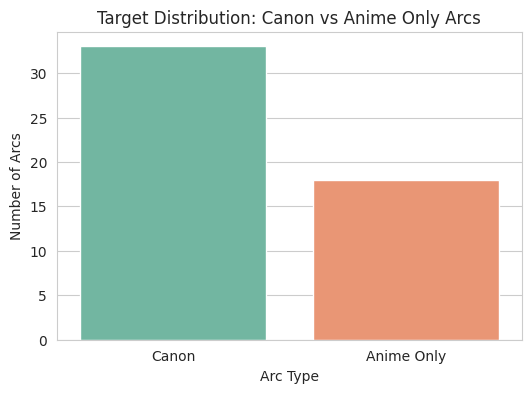

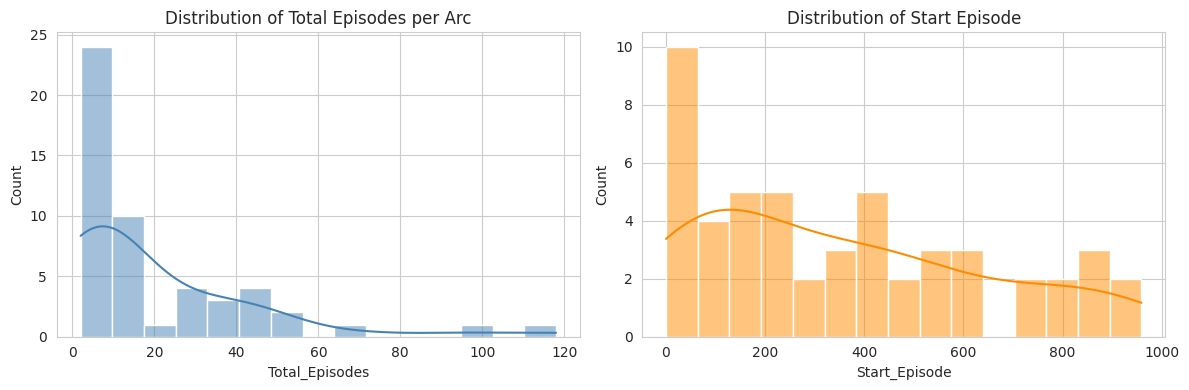

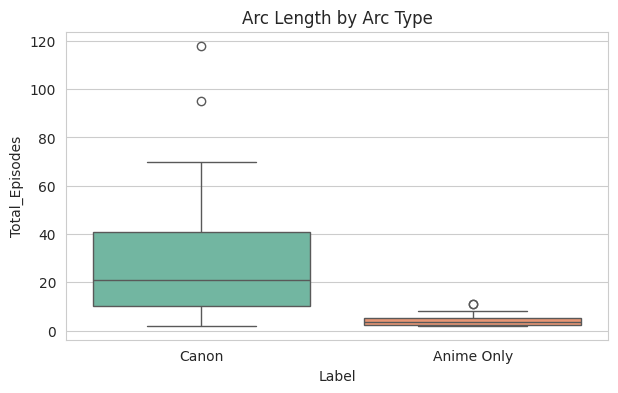

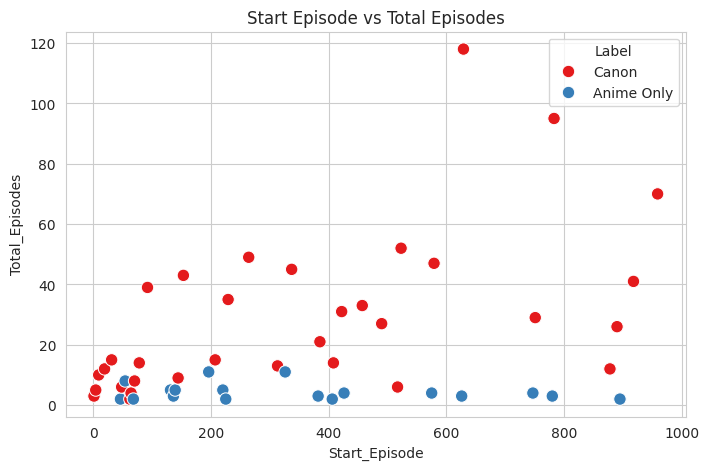

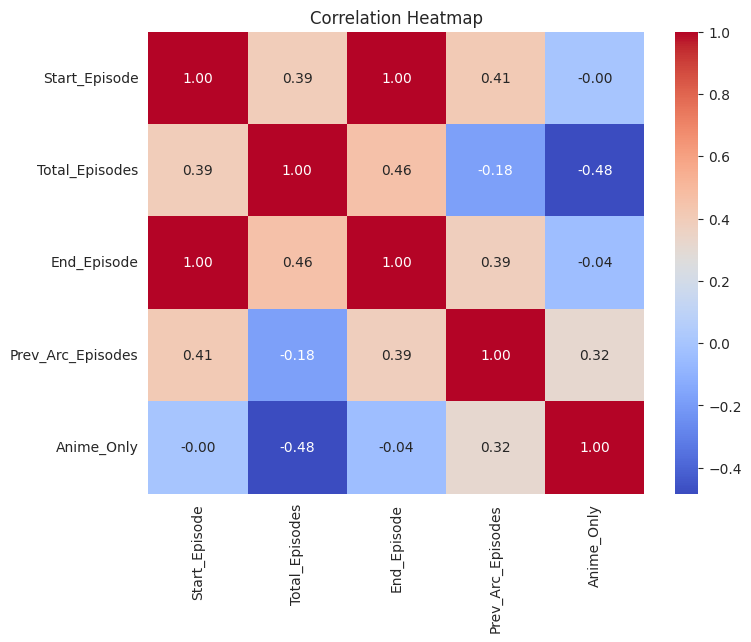

      Model  Train_Acc  Test_Acc  Precision  Recall      F1  ROC_AUC
0   XGBoost      0.975    0.7273        0.6    0.75  0.6667   0.9286
1  LightGBM      1.000    0.7273        0.6    0.75  0.6667   0.8214
XGBoost 5-Fold CV Accuracy: 0.9036 +/- 0.0577
LightGBM 5-Fold CV Accuracy: 0.8436 +/- 0.0785


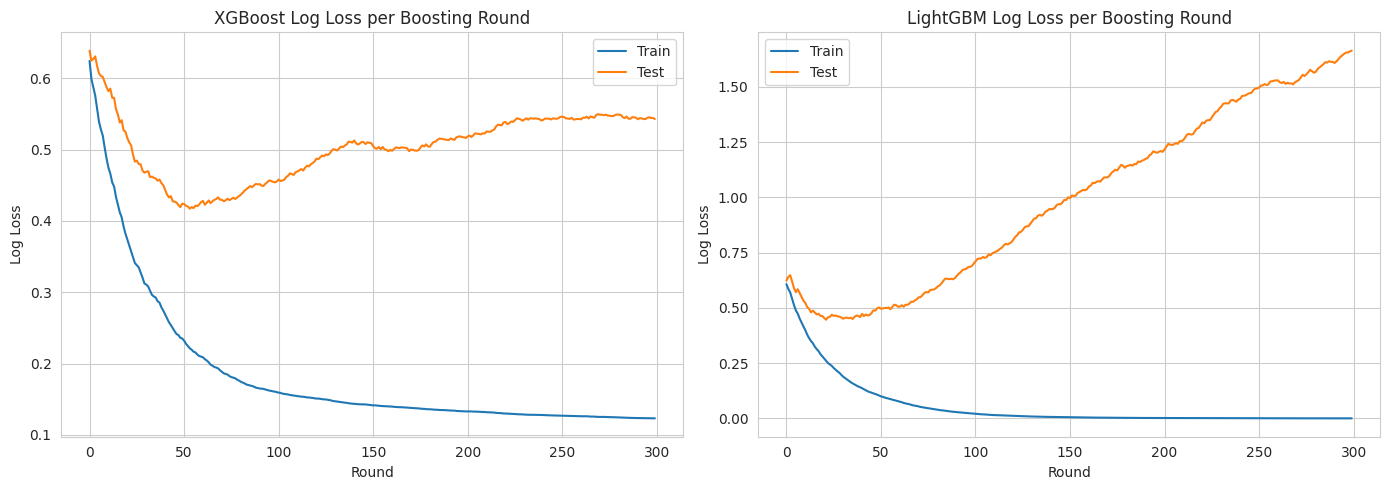

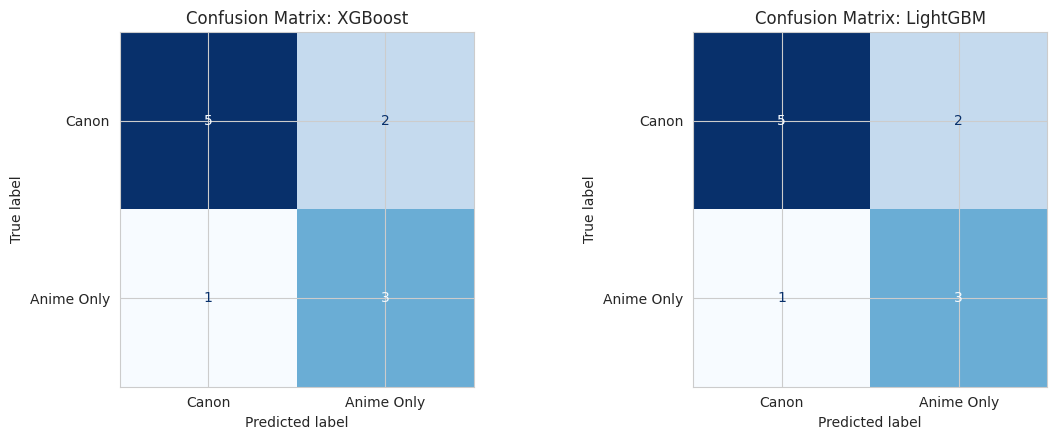

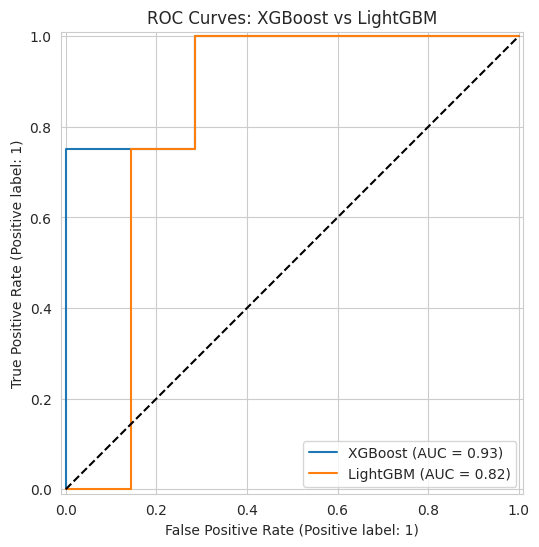

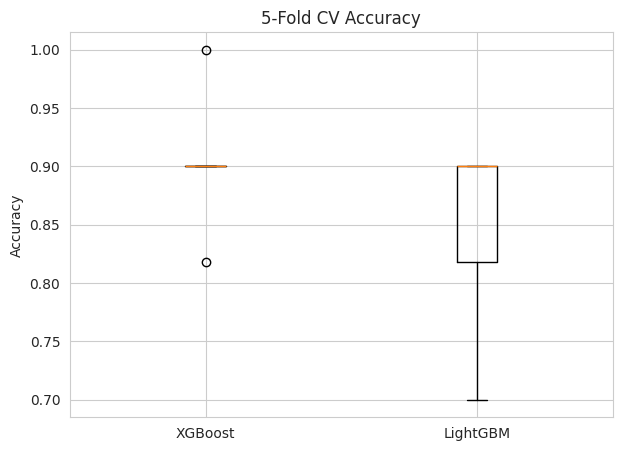

XGBoost SHAP additivity max error: 2.86102294921875e-06
LightGBM SHAP additivity max error: 3.197442310920451e-14


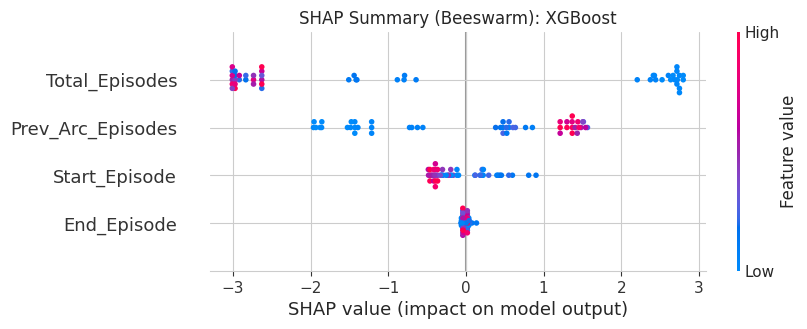

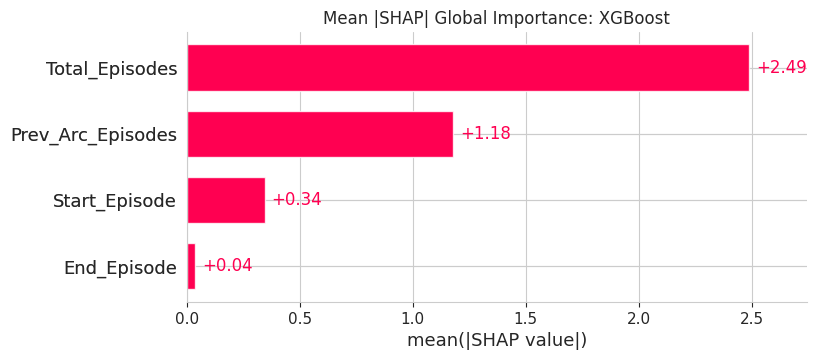

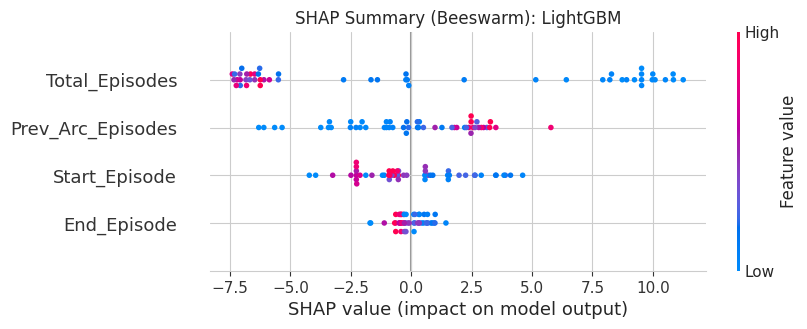

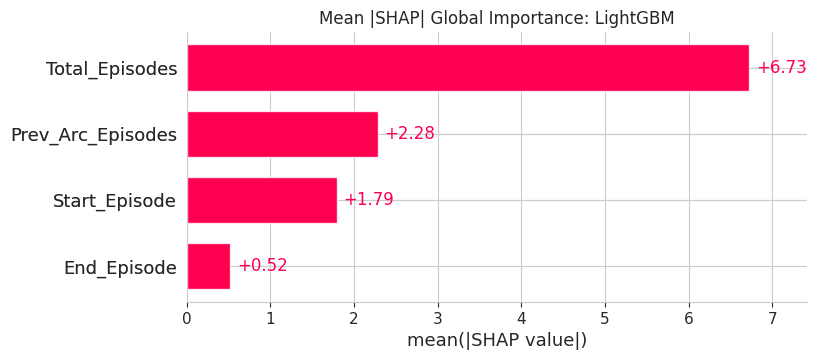

Explaining arc: Whole Cake Island Arc | True label: Canon


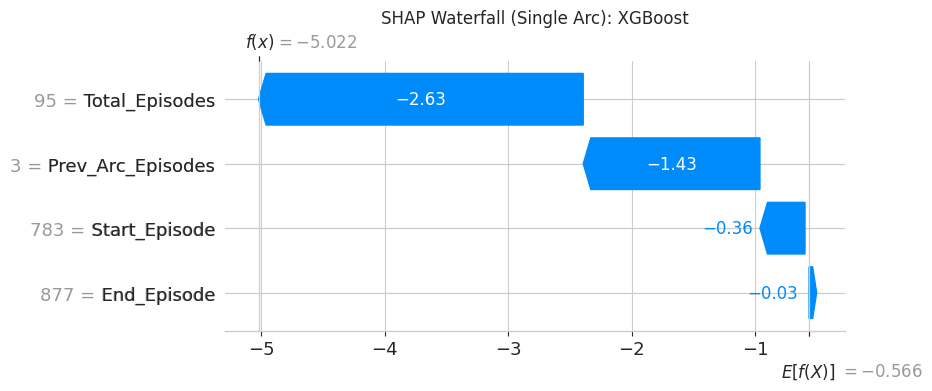

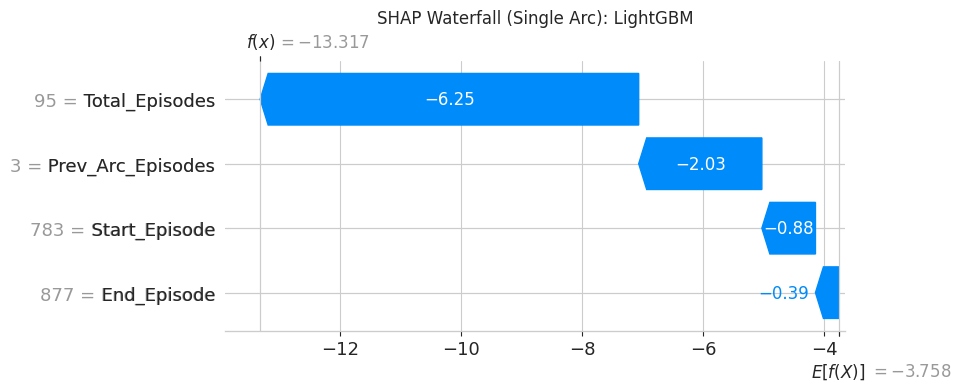

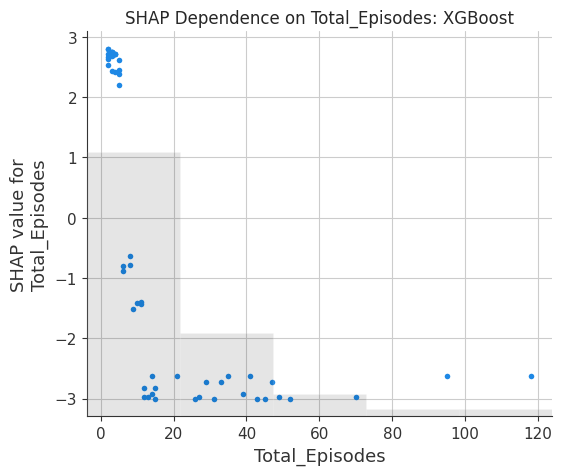

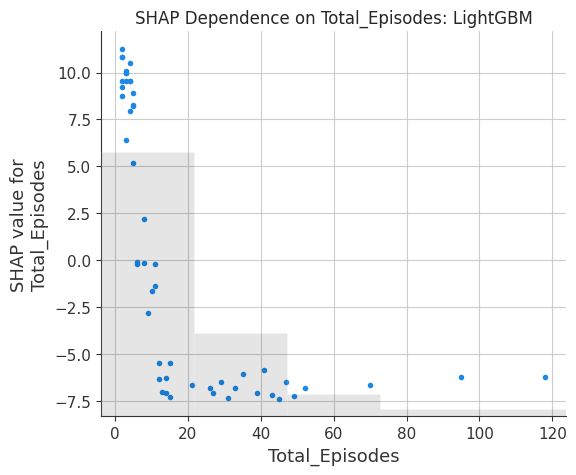

                   XGB_Gain  XGB_MeanAbsSHAP  LGBM_Gain  LGBM_MeanAbsSHAP
Total_Episodes       0.5613           2.4894     0.5290            6.7256
Prev_Arc_Episodes    0.2033           1.1803     0.2111            2.2806
Start_Episode        0.1492           0.3450     0.2062            1.7911
End_Episode          0.0861           0.0375     0.0537            0.5213


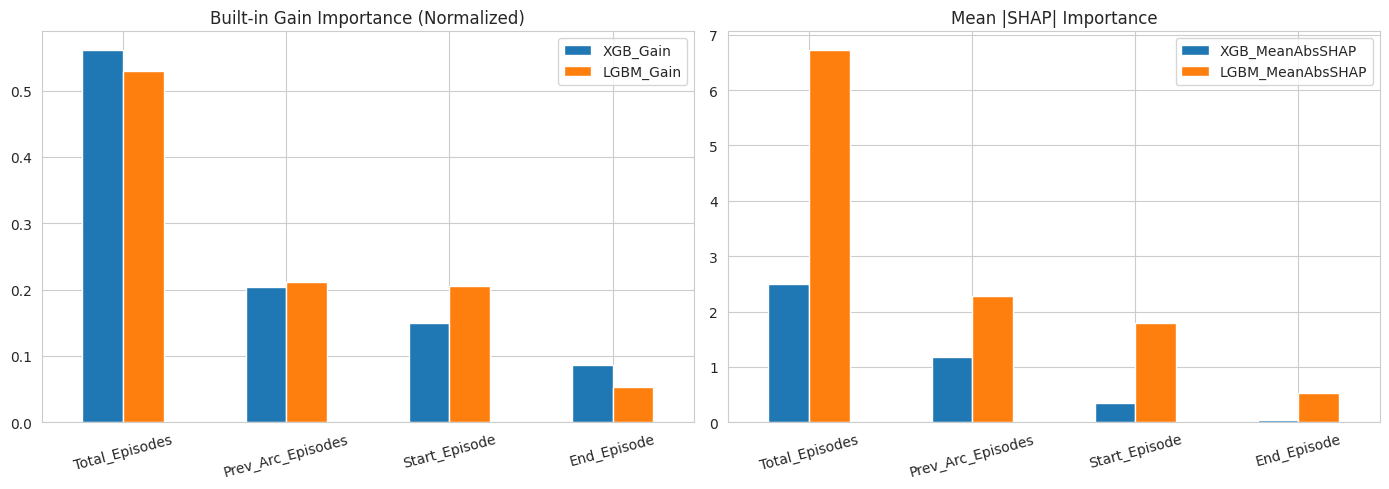

              precision    recall  f1-score   support

       Canon       0.83      0.71      0.77         7
  Anime Only       0.60      0.75      0.67         4

    accuracy                           0.73        11
   macro avg       0.72      0.73      0.72        11
weighted avg       0.75      0.73      0.73        11

              precision    recall  f1-score   support

       Canon       0.83      0.71      0.77         7
  Anime Only       0.60      0.75      0.67         4

    accuracy                           0.73        11
   macro avg       0.72      0.73      0.72        11
weighted avg       0.75      0.73      0.73        11



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip -q install -U fg-data-profiling xgboost lightgbm shap

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files
from data_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PATH = "/content/OnePieceArcs.csv"
print("File found:", os.path.exists(PATH))

df = pd.read_csv(PATH)

print("Shape:", df.shape)
print(df.head())
print(df.tail())
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.describe())
print(df.sample(5, random_state=42))

df = df.rename(columns={
    "Start onChapter": "Start_Chapter",
    "TotalChapters": "Total_Chapters",
    "TotalPages": "Total_Pages",
    "Manga%": "Manga_Pct",
    "Start onEpisode": "Start_Episode",
    "TotalEpisodes": "Total_Episodes",
    "TotalMinutes(avg 24)": "Total_Minutes",
    "Anime%": "Anime_Pct"
})

for col in ["Manga_Pct", "Anime_Pct"]:
    df[col] = df[col].str.rstrip("%").astype(float)

df["Anime_Only"] = (df["Total_Chapters"] == 0).astype(int)
df["Label"] = df["Anime_Only"].map({0: "Canon", 1: "Anime Only"})
df["End_Episode"] = df["Start_Episode"] + df["Total_Episodes"] - 1
df["Prev_Arc_Episodes"] = df["Total_Episodes"].shift(1).fillna(0)

FEATURES = ["Start_Episode", "Total_Episodes", "End_Episode", "Prev_Arc_Episodes"]
CLASS_NAMES = ["Canon", "Anime Only"]

X = df[FEATURES]
y = df["Anime_Only"]

print(df[["Arc", "Total_Chapters", "Total_Episodes", "Anime_Only", "Label"]].head(10))
print(df["Label"].value_counts())
print(df["Label"].value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class balance:", y_train.value_counts().to_dict())
print("Test class balance:", y_test.value_counts().to_dict())

pdf = PdfPages("Exp10_EDA_Report.pdf")

def save():
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()

profile = ProfileReport(df, title="One Piece Arcs EDA - Exp 10 XGBoost LightGBM SHAP", explorative=True, progress_bar=False)
profile.to_file("Exp10_Profile_Report.html")

plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, order=CLASS_NAMES, palette="Set2")
plt.title("Target Distribution: Canon vs Anime Only Arcs")
plt.xlabel("Arc Type")
plt.ylabel("Number of Arcs")
save()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Total_Episodes"], bins=15, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Total Episodes per Arc")
sns.histplot(df["Start_Episode"], bins=15, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Start Episode")
plt.tight_layout()
save()

plt.figure(figsize=(7, 4))
sns.boxplot(x="Label", y="Total_Episodes", data=df, order=CLASS_NAMES, palette="Set2")
plt.title("Arc Length by Arc Type")
save()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Start_Episode", y="Total_Episodes", hue="Label", hue_order=CLASS_NAMES, s=80, palette="Set1")
plt.title("Start Episode vs Total Episodes")
save()

plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES + ["Anime_Only"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
save()

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=8, min_child_samples=3, min_data_in_bin=1, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], eval_metric="logloss")

boosters = {"XGBoost": xgb, "LightGBM": lgbm}

rows = []
for name, m in boosters.items():
    pred = m.predict(X_test)
    rows.append({
        "Model": name,
        "Train_Acc": m.score(X_train, y_train),
        "Test_Acc": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    })
boost_results = pd.DataFrame(rows).round(4)
print(boost_results)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}
for name, m in boosters.items():
    cv_scores[name] = cross_val_score(m, X, y, cv=cv)
    print(name, "5-Fold CV Accuracy: %.4f +/- %.4f" % (cv_scores[name].mean(), cv_scores[name].std()))

xgb_log = xgb.evals_result()
lgbm_log = lgbm.evals_result_
xk = list(xgb_log.keys())
lk = list(lgbm_log.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xgb_log[xk[0]]["logloss"], label="Train")
axes[0].plot(xgb_log[xk[1]]["logloss"], label="Test")
axes[0].set_title("XGBoost Log Loss per Boosting Round")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Log Loss")
axes[0].legend()
axes[1].plot(lgbm_log[lk[0]]["binary_logloss"], label="Train")
axes[1].plot(lgbm_log[lk[1]]["binary_logloss"], label="Test")
axes[1].set_title("LightGBM Log Loss per Boosting Round")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Log Loss")
axes[1].legend()
plt.tight_layout()
save()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, m) in zip(axes, boosters.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, display_labels=CLASS_NAMES, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix: " + name)
plt.tight_layout()
save()

fig, ax = plt.subplots(figsize=(7, 6))
for name, m in boosters.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--")
ax.set_title("ROC Curves: XGBoost vs LightGBM")
save()

plt.figure(figsize=(7, 5))
plt.boxplot(list(cv_scores.values()), labels=list(cv_scores.keys()))
plt.title("5-Fold CV Accuracy")
plt.ylabel("Accuracy")
save()

def explain(model):
    sv = shap.TreeExplainer(model)(X)
    if sv.values.ndim == 3:
        sv = sv[:, :, 1]
    return sv

shap_values = {"XGBoost": explain(xgb), "LightGBM": explain(lgbm)}

raw_output = {"XGBoost": xgb.predict(X, output_margin=True), "LightGBM": lgbm.predict(X, raw_score=True)}
for name, sv in shap_values.items():
    rebuilt = sv.base_values + sv.values.sum(axis=1)
    print(name, "SHAP additivity max error:", float(np.abs(rebuilt - raw_output[name]).max()))

for name, sv in shap_values.items():
    shap.plots.beeswarm(sv, show=False)
    plt.title("SHAP Summary (Beeswarm): " + name)
    save()

    shap.plots.bar(sv, show=False)
    plt.title("Mean |SHAP| Global Importance: " + name)
    save()

row_pos = X.index.get_loc(X_test.index[0])
print("Explaining arc:", df.loc[X_test.index[0], "Arc"], "| True label:", df.loc[X_test.index[0], "Label"])
for name, sv in shap_values.items():
    shap.plots.waterfall(sv[row_pos], show=False)
    plt.title("SHAP Waterfall (Single Arc): " + name)
    save()

for name, sv in shap_values.items():
    top_feature = FEATURES[int(np.argmax(np.abs(sv.values).mean(axis=0)))]
    shap.plots.scatter(sv[:, top_feature], show=False)
    plt.title("SHAP Dependence on " + top_feature + ": " + name)
    save()

gain_xgb = pd.Series(xgb.feature_importances_, index=FEATURES)
gain_lgbm = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"), index=FEATURES)
gain_lgbm = gain_lgbm / gain_lgbm.sum()

importance_table = pd.DataFrame({
    "XGB_Gain": gain_xgb,
    "XGB_MeanAbsSHAP": np.abs(shap_values["XGBoost"].values).mean(axis=0),
    "LGBM_Gain": gain_lgbm,
    "LGBM_MeanAbsSHAP": np.abs(shap_values["LightGBM"].values).mean(axis=0)
}).round(4).sort_values("XGB_MeanAbsSHAP", ascending=False)
print(importance_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_table[["XGB_Gain", "LGBM_Gain"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Built-in Gain Importance (Normalized)")
importance_table[["XGB_MeanAbsSHAP", "LGBM_MeanAbsSHAP"]].plot(kind="bar", ax=axes[1], rot=15)
axes[1].set_title("Mean |SHAP| Importance")
plt.tight_layout()
save()

print(classification_report(y_test, xgb.predict(X_test), target_names=CLASS_NAMES, zero_division=0))
print(classification_report(y_test, lgbm.predict(X_test), target_names=CLASS_NAMES, zero_division=0))

pdf.close()
files.download("Exp10_Profile_Report.html")
files.download("Exp10_EDA_Report.pdf")